# Cybersecurity Network Anomaly Detection Using Machine Learning

In [2]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import os
import joblib

## Load Dataset

In [3]:

train_df = pd.read_parquet(
    "data/UNSW_NB15_training-set.parquet"
)

test_df = pd.read_parquet(
    "data/UNSW_NB15_testing-set.parquet"
)

print("\nDataset Loaded Successfully")



Dataset Loaded Successfully


## Explore the Data

In [4]:
print("\n========== DATASET INFORMATION ==========")

print("Training Shape:", train_df.shape)
print("Testing Shape:", test_df.shape)

print("\nTraining Dataset Info:")
train_df.info()

print("\nTarget Distribution:")
print(train_df["label"].value_counts())

print("\nTarget Percentage:")
print(
    train_df["label"].value_counts(normalize=True) * 100
)


========== DATASET INFORMATION ==========
Training Shape: (82332, 44)
Testing Shape: (82332, 36)

Training Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 44 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   dur                82332 non-null  float32 
 1   proto              82332 non-null  category
 2   service            82332 non-null  category
 3   state              82332 non-null  category
 4   spkts              82332 non-null  int16   
 5   dpkts              82332 non-null  int16   
 6   sbytes             82332 non-null  int32   
 7   dbytes             82332 non-null  int32   
 8   rate               82332 non-null  float32 
 9   sttl               82332 non-null  int16   
 10  dttl               82332 non-null  int16   
 11  sload              82332 non-null  float32 
 12  dload              82332 non-null  float32 
 13  sloss              82332 non-null  int16

## EDA

In [9]:
print("\n========== DATASET INFORMATION ==========")

print("Training Shape:", train_df.shape)
print("Testing Shape:", test_df.shape)

print("\nTraining Dataset Info:")
train_df.info()

print("\nTarget Distribution:")
print(train_df["label"].value_counts())

print("\nTarget Percentage:")
print(
    train_df["label"].value_counts(normalize=True) * 100
)


========== DATASET INFORMATION ==========
Training Shape: (82332, 44)
Testing Shape: (82332, 36)

Training Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 44 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   dur                82332 non-null  float32 
 1   proto              82332 non-null  category
 2   service            82332 non-null  category
 3   state              82332 non-null  category
 4   spkts              82332 non-null  int16   
 5   dpkts              82332 non-null  int16   
 6   sbytes             82332 non-null  int32   
 7   dbytes             82332 non-null  int32   
 8   rate               82332 non-null  float32 
 9   sttl               82332 non-null  int16   
 10  dttl               82332 non-null  int16   
 11  sload              82332 non-null  float32 
 12  dload              82332 non-null  float32 
 13  sloss              82332 non-null  int16

## DATA CLEANING

In [15]:
train = train_df.copy()
test = test_df.copy()

print("\n========== DATA CLEANING ==========")

print("Training duplicates:", train.duplicated().sum())
print("Testing duplicates:", test.duplicated().sum())

print("Training missing values:", train.isnull().sum().sum())
print("Testing missing values:", test.isnull().sum().sum())

train.replace([np.inf, -np.inf], np.nan, inplace=True)
test.replace([np.inf, -np.inf], np.nan, inplace=True)

train.drop_duplicates(inplace=True)
test.drop_duplicates(inplace=True)

train.drop(columns=["id"], inplace=True, errors="ignore")
test.drop(columns=["id"], inplace=True, errors="ignore")

print("\nClean Training Shape:", train.shape)
print("Clean Testing Shape:", test.shape)


========== DATA CLEANING ==========
Training duplicates: 26387
Testing duplicates: 32361
Training missing values: 0
Testing missing values: 0

Clean Training Shape: (55945, 44)
Clean Testing Shape: (49971, 36)


## Feature Engineering

In [16]:
def engineer_features(df):

    df = df.copy()

    df["total_bytes"] = df["sbytes"] + df["dbytes"]

    df["total_packets"] = df["spkts"] + df["dpkts"]

    df["bytes_per_second"] = (
        df["total_bytes"] /
        (df["dur"] + 0.000001)
    )

    df["avg_packet_size"] = (
        df["total_bytes"] /
        (df["total_packets"] + 1)
    )

    df["byte_ratio"] = (
        df["sbytes"] /
        (df["dbytes"] + 1)
    )

    return df


train = engineer_features(train)
test = engineer_features(test)

train.replace([np.inf, -np.inf], np.nan, inplace=True)
test.replace([np.inf, -np.inf], np.nan, inplace=True)

print("\nFeature Engineering Completed")

print("Training Shape after Feature Engineering:", train.shape)
print("Testing Shape after Feature Engineering:", test.shape)

print("\nNew Engineered Features:")

print(
    train[
        [
            "total_bytes",
            "total_packets",
            "bytes_per_second",
            "avg_packet_size",
            "byte_ratio"
        ]
    ].head()
)


Feature Engineering Completed
Training Shape after Feature Engineering: (55945, 49)
Testing Shape after Feature Engineering: (49971, 41)

New Engineered Features:
   total_bytes  total_packets  bytes_per_second  avg_packet_size  byte_ratio
0          496              2      4.133333e+07       165.333333       496.0
1         1762              2      1.957778e+08       587.333333      1762.0
2         1068              2      1.780000e+08       356.000000      1068.0
3          900              2      1.285714e+08       300.000000       900.0
4         2126              2      1.932727e+08       708.666667      2126.0


## FIX CATEGORICAL DATA TYPES

In [13]:
categorical_cols = [
    "proto",
    "service",
    "state"
]

for col in categorical_cols:

    if col in train.columns:
        train[col] = train[col].astype("string")

    if col in test.columns:
        test[col] = test[col].astype("string")


print(
    "\nCategorical Columns Converted Successfully"
)


Categorical Columns Converted Successfully


## Target Separation + Remove Leakage

In [17]:
y_train = train["label"].copy()
y_test = test["label"].copy()

X_train = train.drop(
    columns=["label"],
    errors="ignore"
)

X_test = test.drop(
    columns=["label"],
    errors="ignore"
)

X_train.drop(
    columns=["attack_cat"],
    inplace=True,
    errors="ignore"
)

X_test.drop(
    columns=["attack_cat"],
    inplace=True,
    errors="ignore"
)

print("\nTarget and Input Features Separated")


Target and Input Features Separated


## Check and Align Train/Test Columns

In [18]:
only_train = sorted(
    set(X_train.columns) -
    set(X_test.columns)
)

only_test = sorted(
    set(X_test.columns) -
    set(X_train.columns)
)

print("\nColumns only in Training Data:")
print(only_train)

print("\nColumns only in Testing Data:")
print(only_test)

common_features = X_train.columns.intersection(
    X_test.columns
).tolist()

X_train = X_train[common_features].copy()
X_test = X_test[common_features].copy()

print("\nTrain/Test Features Aligned Successfully")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


Columns only in Training Data:
['ct_dst_ltm', 'ct_dst_src_ltm', 'ct_src_ltm', 'ct_srv_dst', 'ct_srv_src', 'ct_state_ttl', 'dttl', 'sttl']

Columns only in Testing Data:
[]

Train/Test Features Aligned Successfully
X_train shape: (55945, 39)
X_test shape: (49971, 39)
y_train shape: (55945,)
y_test shape: (49971,)


## Identify Numerical and Categorical Columns

In [19]:
categorical_features = [
    col
    for col in categorical_cols
    if col in X_train.columns
]

numeric_features = [
    col
    for col in X_train.columns
    if col not in categorical_features
]

print("\nNumber of Numerical Features:", len(numeric_features))
print("Number of Categorical Features:", len(categorical_features))

print("\nCategorical Columns:")
print(categorical_features)


Number of Numerical Features: 36
Number of Categorical Features: 3

Categorical Columns:
['proto', 'service', 'state']


## Preprocessing Pipeline

In [20]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("\nPreprocessing Pipeline Created Successfully")


Preprocessing Pipeline Created Successfully


## Logistic Regression Model

In [21]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

print("\nTraining Logistic Regression...")

logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression Training Completed")


Training Logistic Regression...
Logistic Regression Training Completed


## Logistic Regression Prediction + Evaluation

In [22]:
logistic_predictions = logistic_pipeline.predict(X_test)

logistic_probabilities = logistic_pipeline.predict_proba(X_test)[:, 1]

log_accuracy = accuracy_score(y_test, logistic_predictions)
log_precision = precision_score(y_test, logistic_predictions)
log_recall = recall_score(y_test, logistic_predictions)
log_f1 = f1_score(y_test, logistic_predictions)
log_auc = roc_auc_score(y_test, logistic_probabilities)

print("\n==========================================")
print("       LOGISTIC REGRESSION RESULTS")
print("==========================================")

print(f"Accuracy  : {log_accuracy:.4f}")
print(f"Precision : {log_precision:.4f}")
print(f"Recall    : {log_recall:.4f}")
print(f"F1 Score  : {log_f1:.4f}")
print(f"ROC-AUC   : {log_auc:.4f}")

print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=["Normal", "Attack"]
    )
)


       LOGISTIC REGRESSION RESULTS
Accuracy  : 0.7500
Precision : 0.6174
Recall    : 0.8404
F1 Score  : 0.7119
ROC-AUC   : 0.8755

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

      Normal       0.88      0.70      0.78     31610
      Attack       0.62      0.84      0.71     18361

    accuracy                           0.75     49971
   macro avg       0.75      0.77      0.75     49971
weighted avg       0.79      0.75      0.75     49971



## Random Forest Model + Evaluation

In [23]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=50,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

print("\nTraining Random Forest...")

random_forest_pipeline.fit(X_train, y_train)

print("Random Forest Training Completed")

rf_predictions = random_forest_pipeline.predict(X_test)
rf_probabilities = random_forest_pipeline.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)
rf_auc = roc_auc_score(y_test, rf_probabilities)

print("\n==========================================")
print("          RANDOM FOREST RESULTS")
print("==========================================")

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")
print(f"ROC-AUC   : {rf_auc:.4f}")

print("\n========== RANDOM FOREST REPORT ==========")

print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=["Normal", "Attack"]
    )
)


Training Random Forest...
Random Forest Training Completed

          RANDOM FOREST RESULTS
Accuracy  : 0.9974
Precision : 0.9966
Recall    : 0.9962
F1 Score  : 0.9964
ROC-AUC   : 0.9997

========== RANDOM FOREST REPORT ==========
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     31610
      Attack       1.00      1.00      1.00     18361

    accuracy                           1.00     49971
   macro avg       1.00      1.00      1.00     49971
weighted avg       1.00      1.00      1.00     49971



## Extra Trees Model + Evaluation

In [24]:
extra_trees_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            ExtraTreesClassifier(
                n_estimators=50,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

print("\nTraining Extra Trees...")

extra_trees_pipeline.fit(X_train, y_train)

print("Extra Trees Training Completed")

extra_predictions = extra_trees_pipeline.predict(X_test)
extra_probabilities = extra_trees_pipeline.predict_proba(X_test)[:, 1]

extra_accuracy = accuracy_score(y_test, extra_predictions)
extra_precision = precision_score(y_test, extra_predictions)
extra_recall = recall_score(y_test, extra_predictions)
extra_f1 = f1_score(y_test, extra_predictions)
extra_auc = roc_auc_score(y_test, extra_probabilities)

print("\n==========================================")
print("            EXTRA TREES RESULTS")
print("==========================================")

print(f"Accuracy  : {extra_accuracy:.4f}")
print(f"Precision : {extra_precision:.4f}")
print(f"Recall    : {extra_recall:.4f}")
print(f"F1 Score  : {extra_f1:.4f}")
print(f"ROC-AUC   : {extra_auc:.4f}")

print("\n========== EXTRA TREES REPORT ==========")

print(
    classification_report(
        y_test,
        extra_predictions,
        target_names=["Normal", "Attack"]
    )
)


Training Extra Trees...
Extra Trees Training Completed

            EXTRA TREES RESULTS
Accuracy  : 0.9975
Precision : 0.9968
Recall    : 0.9965
F1 Score  : 0.9967
ROC-AUC   : 1.0000

========== EXTRA TREES REPORT ==========
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     31610
      Attack       1.00      1.00      1.00     18361

    accuracy                           1.00     49971
   macro avg       1.00      1.00      1.00     49971
weighted avg       1.00      1.00      1.00     49971



## Final Model Comparison

In [25]:
results_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Extra Trees"
    ],
    "Accuracy": [
        log_accuracy,
        rf_accuracy,
        extra_accuracy
    ],
    "Precision": [
        log_precision,
        rf_precision,
        extra_precision
    ],
    "Recall": [
        log_recall,
        rf_recall,
        extra_recall
    ],
    "F1 Score": [
        log_f1,
        rf_f1,
        extra_f1
    ],
    "ROC-AUC": [
        log_auc,
        rf_auc,
        extra_auc
    ]
})

print("\n==========================================")
print("          FINAL MODEL COMPARISON")
print("==========================================")

print(
    results_df.sort_values(
        by="F1 Score",
        ascending=False
    )
)


          FINAL MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
2          Extra Trees  0.997539   0.996786  0.996514  0.996650  0.999987
1        Random Forest  0.997358   0.996568  0.996242  0.996405  0.999736
0  Logistic Regression  0.750015   0.617413  0.840423  0.711860  0.875462


## Hyperparameter Tuning for Extra Trees

In [27]:
extra_param_grid = {
    "model__n_estimators": [50, 100, 150, 200],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

extra_random_search = RandomizedSearchCV(
    estimator=extra_trees_pipeline,
    param_distributions=extra_param_grid,
    n_iter=5,
    scoring="f1",
    cv=2,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("\nStarting Extra Trees Hyperparameter Tuning...")

extra_random_search.fit(X_train, y_train)

print("\nExtra Trees Hyperparameter Tuning Completed")

print("\nBest Parameters:")
print(extra_random_search.best_params_)

print("\nBest Cross Validation F1 Score:")
print(extra_random_search.best_score_)


Starting Extra Trees Hyperparameter Tuning...
Fitting 2 folds for each of 5 candidates, totalling 10 fits

Extra Trees Hyperparameter Tuning Completed

Best Parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': None}

Best Cross Validation F1 Score:
0.5524553721939843


## Tuned Extra Trees Evaluation

In [28]:
best_model = extra_random_search.best_estimator_

tuned_predictions = best_model.predict(X_test)

tuned_probabilities = best_model.predict_proba(X_test)[:, 1]

tuned_accuracy = accuracy_score(y_test, tuned_predictions)
tuned_precision = precision_score(y_test, tuned_predictions)
tuned_recall = recall_score(y_test, tuned_predictions)
tuned_f1 = f1_score(y_test, tuned_predictions)
tuned_auc = roc_auc_score(y_test, tuned_probabilities)

print("\n==========================================")
print("       TUNED EXTRA TREES RESULTS")
print("==========================================")

print(f"Accuracy  : {tuned_accuracy:.4f}")
print(f"Precision : {tuned_precision:.4f}")
print(f"Recall    : {tuned_recall:.4f}")
print(f"F1 Score  : {tuned_f1:.4f}")
print(f"ROC-AUC   : {tuned_auc:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        tuned_predictions,
        target_names=["Normal", "Attack"]
    )
)


       TUNED EXTRA TREES RESULTS
Accuracy  : 0.9975
Precision : 0.9968
Recall    : 0.9965
F1 Score  : 0.9967
ROC-AUC   : 1.0000

Classification Report:

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     31610
      Attack       1.00      1.00      1.00     18361

    accuracy                           1.00     49971
   macro avg       1.00      1.00      1.00     49971
weighted avg       1.00      1.00      1.00     49971



## Confusion Matrix

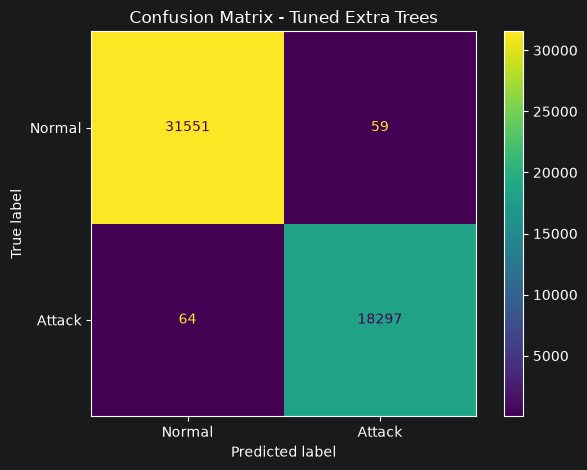

In [29]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_predictions,
    display_labels=["Normal", "Attack"]
)

plt.title("Confusion Matrix - Tuned Extra Trees")
plt.tight_layout()
plt.show()

## ROC Curve

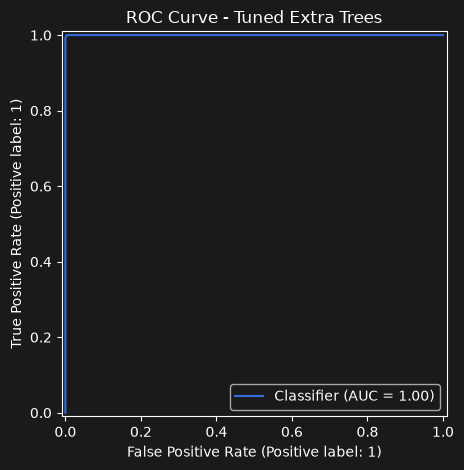

In [30]:
RocCurveDisplay.from_predictions(
    y_test,
    tuned_probabilities
)

plt.title("ROC Curve - Tuned Extra Trees")
plt.tight_layout()
plt.show()

## Feature Importance


Top 15 Important Features:
                   Feature  Importance
184         cat__state_INT    0.092889
18             num__tcprtt    0.081355
20             num__ackdat    0.081114
183         cat__state_FIN    0.070006
5                num__rate    0.062038
7               num__dload    0.053906
19             num__synack    0.051806
22              num__dmean    0.045868
34    num__avg_packet_size    0.038827
21              num__smean    0.034896
167         cat__service_-    0.032872
35         num__byte_ratio    0.025941
25   num__ct_src_dport_ltm    0.021875
3              num__sbytes    0.021781
153         cat__proto_udp    0.021476


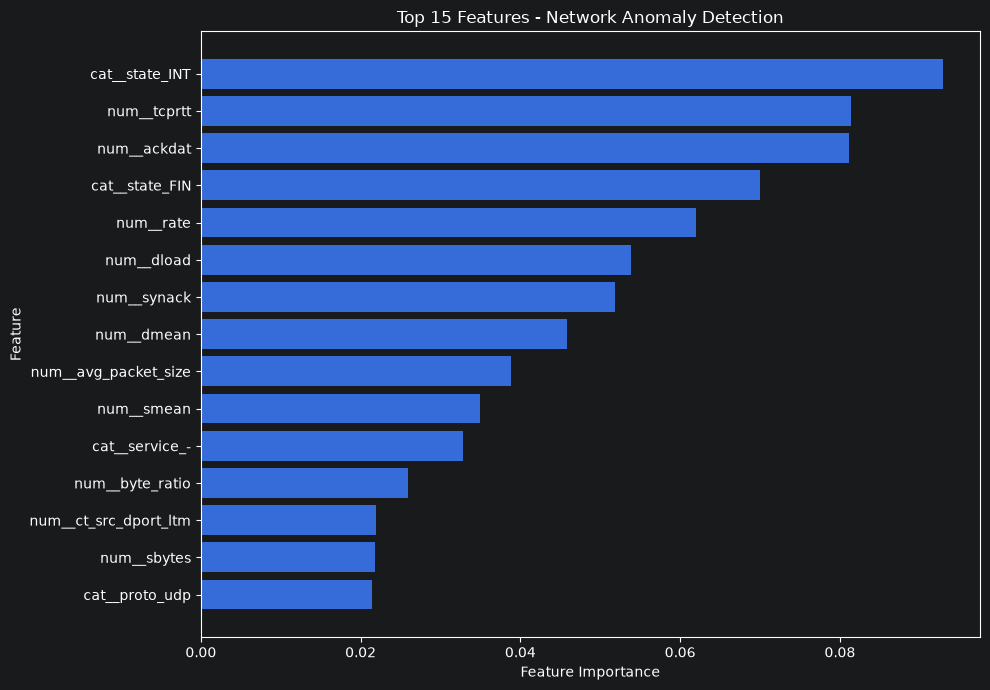

In [31]:
final_extra_model = best_model.named_steps["model"]

feature_names = (
    best_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": final_extra_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 15 Important Features:")
print(feature_importance_df.head(15))

top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features - Network Anomaly Detection")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Original vs Tuned Extra Trees

In [32]:
comparison_tuned = pd.DataFrame({
    "Model": [
        "Original Extra Trees",
        "Tuned Extra Trees"
    ],
    "Accuracy": [
        extra_accuracy,
        tuned_accuracy
    ],
    "Precision": [
        extra_precision,
        tuned_precision
    ],
    "Recall": [
        extra_recall,
        tuned_recall
    ],
    "F1 Score": [
        extra_f1,
        tuned_f1
    ],
    "ROC-AUC": [
        extra_auc,
        tuned_auc
    ]
})

print("\n========== ORIGINAL VS TUNED ==========")
print(comparison_tuned)


========== ORIGINAL VS TUNED ==========
                  Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Original Extra Trees  0.997539   0.996786  0.996514   0.99665  0.999987
1     Tuned Extra Trees  0.997539   0.996786  0.996514   0.99665  0.999987


## Save Model and Outputs

In [33]:
os.makedirs("model", exist_ok=True)
os.makedirs("images", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

joblib.dump(
    best_model,
    "model/cybersecurity_anomaly_detector.pkl"
)

print("\nFinal tuned model saved successfully.")

final_metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1,
        tuned_auc
    ]
})

final_metrics_df.to_csv(
    "outputs/final_model_metrics.csv",
    index=False
)

results_df.to_csv(
    "outputs/model_comparison.csv",
    index=False
)

feature_importance_df.to_csv(
    "outputs/feature_importance.csv",
    index=False
)

print("\nMetrics and feature importance saved successfully.")


Final tuned model saved successfully.

Metrics and feature importance saved successfully.


## Save Graph Images

In [34]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_predictions,
    display_labels=["Normal", "Attack"]
)

plt.title("Confusion Matrix - Tuned Extra Trees")
plt.tight_layout()

plt.savefig(
    "images/confusion_matrix.png",
    dpi=300
)

plt.close()

print("Confusion matrix image saved.")


RocCurveDisplay.from_predictions(
    y_test,
    tuned_probabilities
)

plt.title("ROC Curve - Tuned Extra Trees")
plt.tight_layout()

plt.savefig(
    "images/roc_curve.png",
    dpi=300
)

plt.close()

print("ROC curve image saved.")


top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features - Network Anomaly Detection")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "images/feature_importance.png",
    dpi=300
)

plt.close()

print("Feature importance image saved.")

Confusion matrix image saved.
ROC curve image saved.
Feature importance image saved.


## Final Project Summary

In [35]:
print("\n==========================================")
print("          FINAL PROJECT SUMMARY")
print("==========================================")

print("Project: Cybersecurity Network Anomaly Detection")
print("Dataset: UNSW-NB15")
print("Best Model: Tuned Extra Trees Classifier")

print("\nFinal Model Performance:")
print(final_metrics_df)

print("\nTop 5 Important Features:")
print(feature_importance_df.head(5))

print("\nProject outputs saved in:")
print("1. model/cybersecurity_anomaly_detector.pkl")
print("2. outputs/final_model_metrics.csv")
print("3. outputs/model_comparison.csv")
print("4. outputs/feature_importance.csv")
print("5. images/confusion_matrix.png")
print("6. images/roc_curve.png")
print("7. images/feature_importance.png")


          FINAL PROJECT SUMMARY
Project: Cybersecurity Network Anomaly Detection
Dataset: UNSW-NB15
Best Model: Tuned Extra Trees Classifier

Final Model Performance:
      Metric     Score
0   Accuracy  0.997539
1  Precision  0.996786
2     Recall  0.996514
3   F1 Score  0.996650
4    ROC-AUC  0.999987

Top 5 Important Features:
            Feature  Importance
184  cat__state_INT    0.092889
18      num__tcprtt    0.081355
20      num__ackdat    0.081114
183  cat__state_FIN    0.070006
5         num__rate    0.062038

Project outputs saved in:
1. model/cybersecurity_anomaly_detector.pkl
2. outputs/final_model_metrics.csv
3. outputs/model_comparison.csv
4. outputs/feature_importance.csv
5. images/confusion_matrix.png
6. images/roc_curve.png
7. images/feature_importance.png


## SAVE FEATURE COLUMNS FOR STREAMLIT APP

In [36]:
joblib.dump(
    common_features,
    "model/feature_columns.pkl"
)

joblib.dump(
    categorical_cols,
    "model/categorical_columns.pkl"
)

X_train.head(1).to_csv(
    "outputs/sample_input_template.csv",
    index=False
)

print("Feature columns saved successfully.")
print("Sample input template saved successfully.")

Feature columns saved successfully.
Sample input template saved successfully.
